         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
3  1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
4  1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  


/tmp/ipykernel_14287/1668824014.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["neutral"] = X["neutral"].astype(int)


=== Pipeline Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.69      0.70      0.69      7591
           1       0.68      0.66      0.67      7208

    accuracy                           0.68     14799
   macro avg       0.68      0.68      0.68     14799
weighted avg       0.68      0.68      0.68     14799



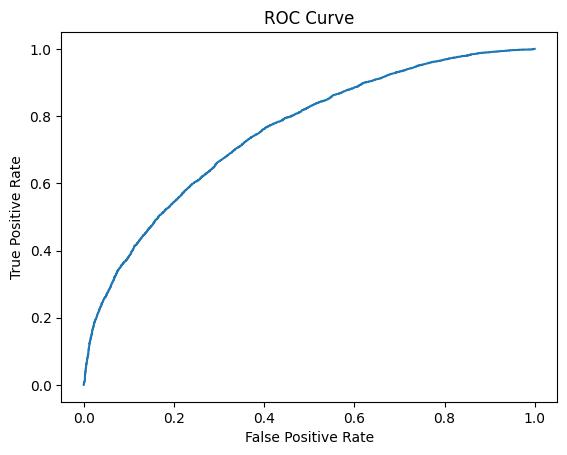

AUC: 0.7533549462964423


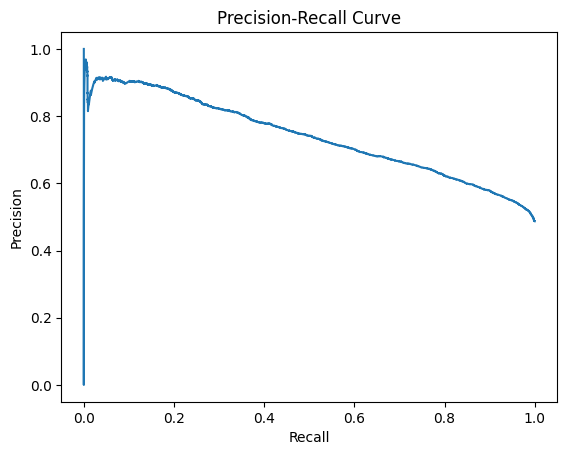

=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.66      0.62      0.64      7591
           1       0.62      0.66      0.64      7208

    accuracy                           0.64     14799
   macro avg       0.64      0.64      0.64     14799
weighted avg       0.64      0.64      0.64     14799

=== XGBoost Report ===
              precision    recall  f1-score   support

           0       0.91      0.04      0.07      7591
           1       0.50      1.00      0.66      7208

    accuracy                           0.50     14799
   macro avg       0.70      0.52      0.37     14799
weighted avg       0.71      0.50      0.36     14799



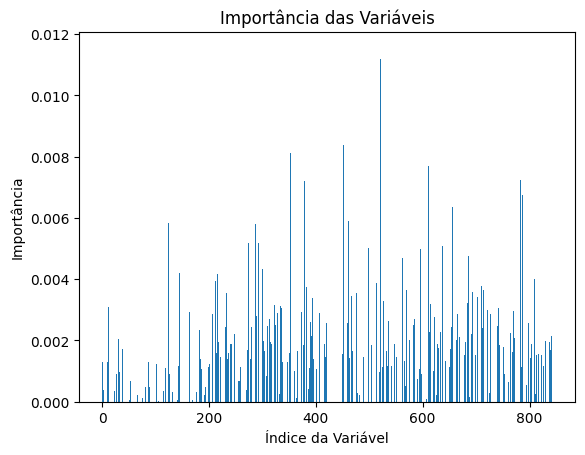

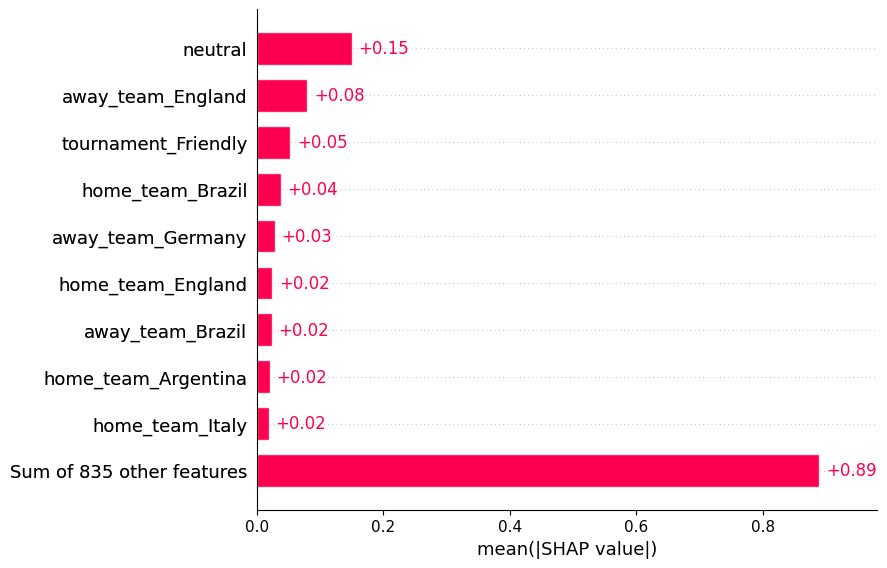

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap


# Importação do dataset
url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df = pd.read_csv(url)

print(df.head())

# Variável alvo (resultado do jogo)
df["is_home_win"] = (df["home_score"] > df["away_score"]).astype(int)

# Features pré-jogo
X = df[["neutral", "tournament", "home_team", "away_team"]]

# Converter booleano para inteiro
X["neutral"] = X["neutral"].astype(int)

# Transformar variáveis categóricas em dummies
X = pd.get_dummies(X, drop_first=True)

y = df["is_home_win"]

# Divisão treino/teste (70% treino, 30% teste)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Pipeline com Regressão Logística
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),  # trata NaN
    ("scaler", StandardScaler(with_mean=False)),           # padroniza
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

print("=== Pipeline Logistic Regression Report ===")
print(classification_report(y_test, y_pred))

# Curvas de avaliação
y_probs = pipeline.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()
print("AUC:", roc_auc_score(y_test, y_probs))

precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Balanceamento com SMOTE
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(x_train_res, y_train_res)
y_pred_rf = rf.predict(x_test)
print("=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))

# XGBoost
xgb = XGBClassifier(scale_pos_weight=10, eval_metric="logloss", random_state=42)
xgb.fit(x_train_res, y_train_res)
y_pred_xgb = xgb.predict(x_test)
print("=== XGBoost Report ===")
print(classification_report(y_test, y_pred_xgb))

# Importância das variáveis
importancias = xgb.feature_importances_
plt.bar(range(len(importancias)), importancias)
plt.title("Importância das Variáveis")
plt.xlabel("Índice da Variável")
plt.ylabel("Importância")
plt.show()

# Explicabilidade com SHAP
explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])
shap.plots.bar(shap_values)

